In [1]:
#open what is needed to open fits files 
from astropy.io import fits
#import numpy 
import numpy as np 
import sys
sys.path.append("../")

In [2]:
from pyACC.fits_wrapper.fits_manager import FitsManager


In [3]:
input_file= "BGS_BRIGHT-21.5_NGC_clustering.dat.fits"
#leggo ra dec e z del primo file

In [4]:
desi_catalogue= FitsManager(input_file)

2025-06-20 13:22:43.836969 :: FitsManager :: INFO :: Fits open succesfully


In [5]:
desi_catalogue.get_hdu_count()

2

In [6]:
data= desi_catalogue.get_data(1)

In [7]:
desi_catalogue.get_header(1)


XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  117 / length of dimension 1                          
NAXIS2  =               217614 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   18 / number of table fields                         
TTYPE1  = 'TARGETID'                                                            
TFORM1  = 'K       '                                                            
TTYPE2  = 'Z       '                                                            
TFORM2  = 'D       '                                                            
TTYPE3  = 'NTILE   '        

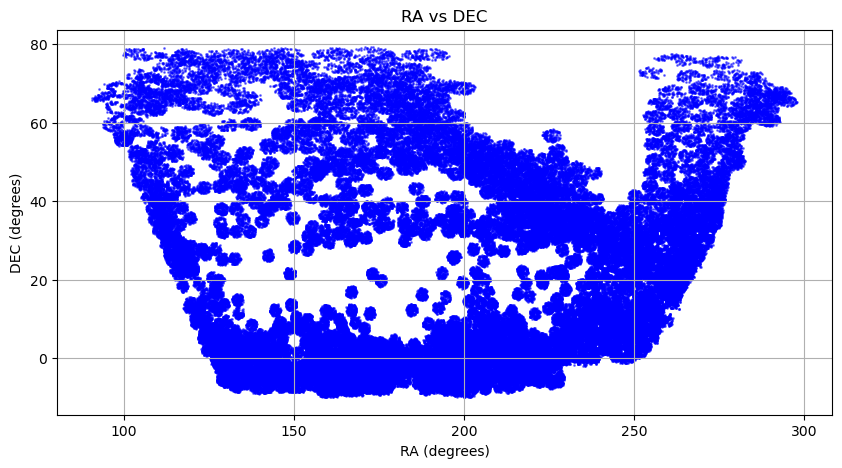

In [8]:
#plot ra vs dec
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.scatter(data['RA'], data['DEC'], s=1, c='blue', alpha=0.5)
plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')
plt.title('RA vs DEC')

plt.grid()
plt.show()

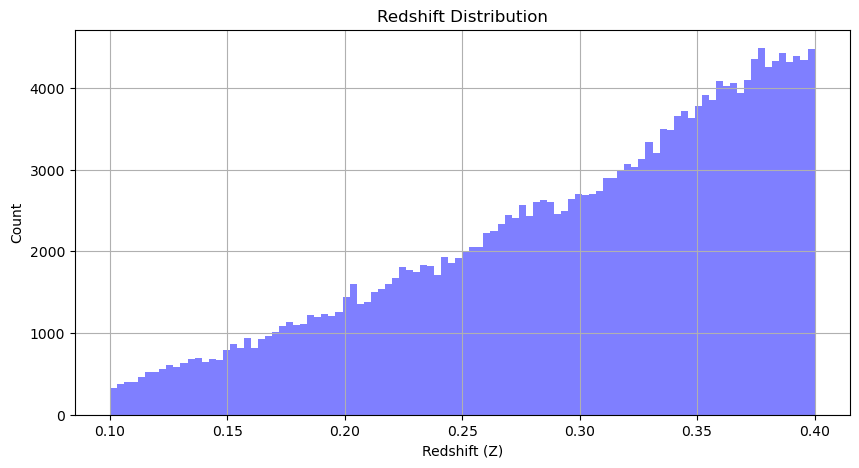

In [9]:
#plot n di z
plt.figure(figsize=(10, 5))
plt.hist(data['Z'], bins=100, color='blue', alpha=0.5)
#confronto istogramma con random
#plt.hist(data['Z'], bins=100, color='red', alpha=0.5, label='Random')

plt.xlabel('Redshift (Z)')
plt.ylabel('Count')
plt.title('Redshift Distribution')

plt.grid()
plt.show()

In [10]:
print(data.columns.names)

['TARGETID', 'Z', 'NTILE', 'RA', 'DEC', 'PHOTSYS', 'FRAC_TLOBS_TILES', 'WEIGHT_ZFAIL', 'WEIGHT_SYS', 'WEIGHT', 'WEIGHT_COMP', 'flux_g_dered', 'flux_r_dered', 'flux_z_dered', 'flux_w1_dered', 'flux_w2_dered', 'NX', 'WEIGHT_FKP']


2025-06-20 13:22:46.466235 :: FitsManager :: INFO :: Fits open succesfully


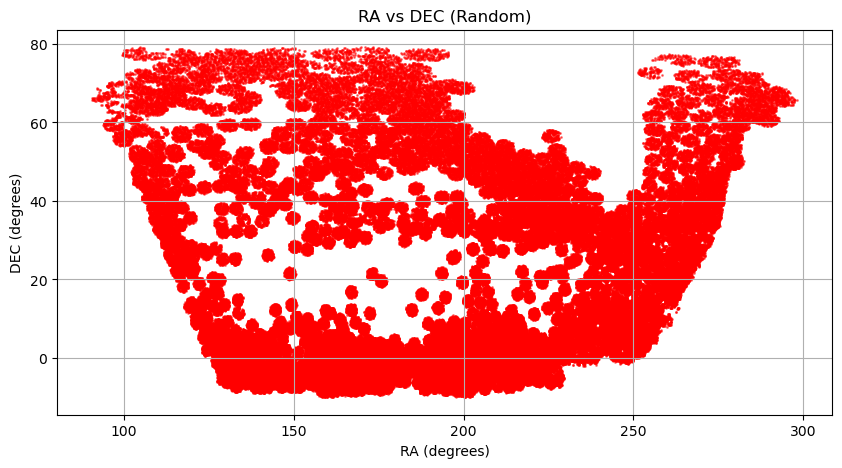

In [11]:
## READ DATA 
#/home/asiat/astrocosmolib/test/BGS_BRIGHT-21.5_NGC_17_clustering.ran.fits

random_file= "BGS_BRIGHT-21.5_NGC_17_clustering.ran.fits"
random_catalogue= FitsManager(random_file)
data_ra, data_dec, data_redshift, data_weight= data["RA"], data["DEC"], data["Z"], data["WEIGHT"]
random_data= random_catalogue.get_data(1)
random_ra, random_dec, random_red, random_weight = random_data["RA"], random_data["DEC"], random_data["Z"], random_data["WEIGHT"]


random_idx= np.random.choice(len(random_ra), size=len(data_ra), replace=False)
random_ra= random_ra[random_idx]
random_dec= random_dec[random_idx]
random_redshift= random_red[random_idx]
random_weight= random_weight[random_idx]

plt.figure(figsize=(10, 5))
plt.scatter(random_ra, random_dec, s=1, c='red', alpha=0.5)
plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')
plt.title('RA vs DEC (Random)')
plt.grid()
plt.show()

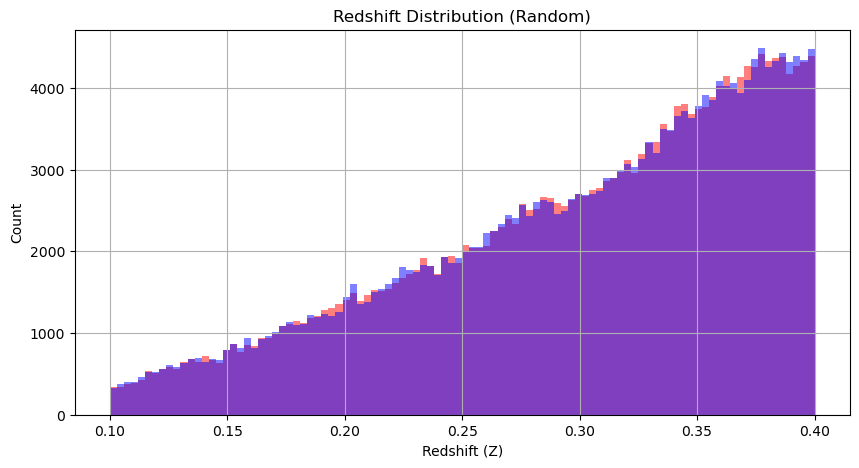

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(random_redshift, bins=100, color='red', alpha=0.5)
plt.hist(data_redshift, bins=100, color='blue', alpha=0.5, label='Original')
plt.xlabel('Redshift (Z)')
plt.ylabel('Count')
plt.title('Redshift Distribution (Random)')
plt.grid()
plt.show()

In [40]:
#convert to comoving coordinates
from astropy.cosmology import FlatLambdaCDM

def equatorial_to_comoving(ra, dec, redshift, Om0):
    """
    Convert equatorial coordinates (RA, DEC) to comoving coordinates (x, y, z).
    
    Parameters:
    ra : float
        Right Ascension in degrees.
    dec : float
        Declination in degrees.
    redshift : float
        Redshift.
    Om0 : float
        Matter density parameter.
    
    Returns:
    tuple of floats
        Comoving coordinates (x, y, z).
    """
    # Define cosmology
    #H0= 100 o 70 
    cosmo = FlatLambdaCDM(H0=100, Om0=Om0)
    
    # Convert RA and DEC to radians
    ra_rad = np.radians(ra)
    dec_rad = np.radians(dec)
    
    # Calculate comoving distance
    comoving_distance = cosmo.comoving_distance(redshift).value
    
    # Calculate x, y, z coordinates
    x = comoving_distance * np.cos(dec_rad) * np.cos(ra_rad)
    y = comoving_distance * np.cos(dec_rad) * np.sin(ra_rad)
    z = comoving_distance * np.sin(dec_rad)
    
    return x, y, z

In [41]:
omega_matter= 0.3
#sono in coordinate equatoriali perchè così le legge il telescopio 
#convert data coordinates to comoving coordinates

#data_ra, data_dec, data_red, data_weight= data["RA"], data["DEC"], data["Z"], data["WEIGHT"]
data_x, data_y, data_z = equatorial_to_comoving(data_ra, data_dec, data_redshift, omega_matter)


In [42]:
print(len(random_ra[::30]), len(random_dec[::30]), len(random_redshift[::30]))


7254 7254 7254


In [43]:
#Convert random coordinates to comoving coordinates
rand_x, rand_y, rand_z= equatorial_to_comoving(random_ra, random_dec, random_redshift, omega_matter)

In [44]:
import Corrfunc
from Corrfunc.theory import DD

#0.1 rmin 

r_min=0
r_max= 150
n_bins=35

#stavamo plottando la cosa senza pesi 

r_edges= np.linspace(r_min, r_max, n_bins+1)
r_centers= 0.5*(r_edges[1:]+ r_edges[:-1])

print(r_edges)

[  0.           4.28571429   8.57142857  12.85714286  17.14285714
  21.42857143  25.71428571  30.          34.28571429  38.57142857
  42.85714286  47.14285714  51.42857143  55.71428571  60.
  64.28571429  68.57142857  72.85714286  77.14285714  81.42857143
  85.71428571  90.          94.28571429  98.57142857 102.85714286
 107.14285714 111.42857143 115.71428571 120.         124.28571429
 128.57142857 132.85714286 137.14285714 141.42857143 145.71428571
 150.        ]


In [45]:
DD= Corrfunc.theory.DD(
    autocorr=True,
    nthreads=4,
    binfile=r_edges,
    X1= data_x,
    Y1= data_y,
    Z1= data_z,
    weights1= data_weight.tolist(),
    weight_type="pair_product",
    periodic= False,
    verbose= True,
    
)

In [46]:
#ora voglio fare RR
RR= Corrfunc.theory.DD(
    autocorr=True,
    nthreads=4,
    binfile=r_edges,
    X1= rand_x,
    Y1= rand_y,
    Z1= rand_z,
    weights1= random_weight.tolist(),
    weight_type="pair_product",
    periodic= False,
    verbose= True,
    
)

In [47]:
#ora voglio fare DR
DR= Corrfunc.theory.DD(
    autocorr=False,
    nthreads=4,
    binfile=r_edges,
    X1= data_x,
    Y1= data_y,
    Z1= data_z,
    X2= rand_x,
    Y2= rand_y,
    Z2= rand_z,
    weights1= data_weight.tolist(),
    weights2= random_weight.tolist(),
    weight_type="pair_product",
    periodic= False,
    verbose= True,
    
)

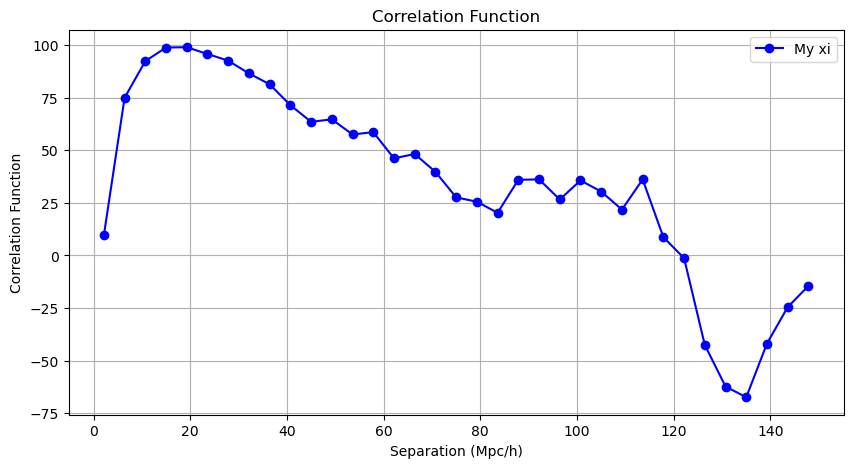

In [48]:
#scrivo lo stimatore a mano 
DD_norm= DD["npairs"] * DD['weightavg']/ np.sum(data_weight)**2
RR_norm= RR["npairs"] * RR['weightavg']/ np.sum(random_weight)**2
DR_norm= DR["npairs"] * DR['weightavg']/ (np.sum(data_weight)*np.sum(random_weight))

my_xi= (DD_norm- 2*DR_norm + RR_norm)/ RR_norm

s = [22.07520600558678, 26.2534785865071, 30.222832756727904, 33.98328445509419, 38.161557036014514, 41.922008734380796, 46.30919175657813, 50.06962751609943, 54.45682647714176, 58.21726223666305, 62.186624376306355, 65.5292392532736, 69.91642227547095, 74.51253167779029, 77.43732567220351, 81.61559825312384, 85.58494445392216, 89.55430659356546, 93.73257917448578, 98.11976219668311, 101.67130345377238, 105.01391833073964, 110.65457993944408, 113.99721075525632, 117.75764651477762, 121.72700865442091, 126.11419167661826, 130.08355381626154, 133.63507913450584, 137.60444127414914, 141.57380341379246, 145.54316555343576, 148.885780430403, 153.8997107152764, 157.8690728549197, 161.42059817316397, 165.59888669292928, 169.98605377628164, 173.7465054746479, 177.71585167544623, 181.4763033738125, 186.28132321740887, 189.6239540332211, 193.38437385389742, 197.98049919506175]
s2xi = [92.88537883146178, 89.32806070826561, 84.58496736436169, 81.02767185794671, 73.51778474357886, 63.24111139767411, 63.636369804576695, 56.52174109711141, 51.778662831061624, 52.56917210593972, 44.664034123596345, 38.33992976886328, 37.94466382303364, 29.249009026885105, 26.086956849518558, 17.391302053370012, 25.296440035713402, 17.391302053370012, 20.158103362761054, 24.505938299762377, 26.87747366332374, 24.901189167737883, 30.03952584069026, 33.59684396388644, 5.928861025684597, -8.69564725722148, -22.529668882030634, -22.92490467215204, -35.57311338161813, -34.78259656781299, -26.482237873202337, -15.019751611954533, -15.810268425759702, -7.905130443416326, -16.600785239564857, -19.76283741693139, -24.505953377616507, -34.78259656781299, -43.87351730979117, -66.40314849718646, -80.63240591211704, -94.86164824919348, -85.77075766292359, -82.60869040770294, -61.66007777006374]


#ora voglio fare il plot
plt.figure(figsize=(10, 5))
plt.plot(r_centers, r_centers**2 * my_xi, marker='o', linestyle='-', color='blue', label='My xi')
plt.xlabel('Separation (Mpc/h)')
plt.ylabel('Correlation Function')
plt.title('Correlation Function')
plt.grid()
plt.legend()
plt.show()

In [49]:
#ORA date le coppie funzione che mi calcoli la funzione di correlazione
#abbiamo i conteggi servono solo le normalizzazioni e la formula
from Corrfunc.utils import convert_3d_counts_to_cf
xi= convert_3d_counts_to_cf(len(data_x), len(data_x),len(rand_x), len(rand_x),DD,DR,DR,RR, estimator='LS')

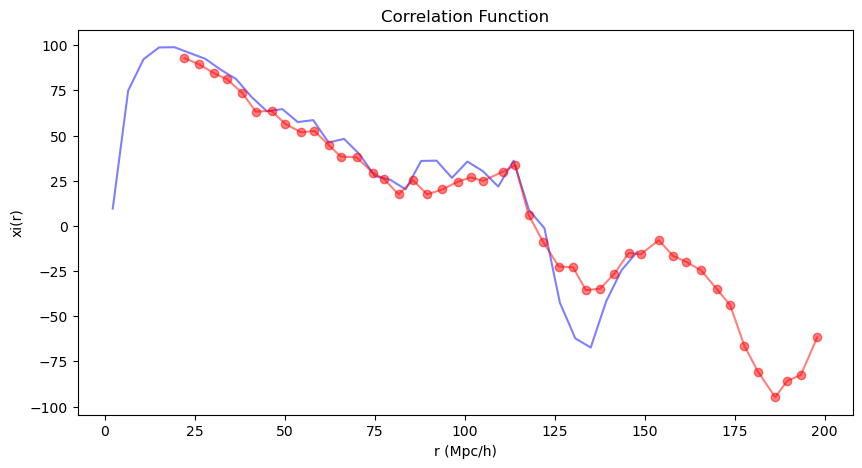

In [50]:
#ora provo a dare il plot
plt.figure(figsize=(10, 5))
plt.plot(r_centers, r_centers**2 *my_xi, color='blue', alpha=0.5)
plt.plot(s, s2xi, color='red',marker='o', alpha=0.5, label='s2xi')
plt.xlabel('r (Mpc/h)')
plt.ylabel('xi(r)')
plt.title('Correlation Function')
plt.show()